In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
file_path = "/content/drive/MyDrive/Celestial/Linear-regression/dataset/house_price_dataset.csv"
df=pd.read_csv(file_path)
df.head()

,house_size_sqft,num_bedrooms,house_age_years,location_type,distance_to_city_km,house_price
0,3674.0,4,23,Suburban,5.487522,1.249977e+06
1,1360.0,2,30,Suburban,45.948365,3.441428e+05
2,1794.0,3,5,Suburban,7.704113,6.155513e+05
3,1630.0,4,1,Suburban,47.561630,4.945589e+05
4,1595.0,5,19,Suburban,22.854283,7.666018e+05


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   house_size_sqft      475 non-null    float64
 1   num_bedrooms         500 non-null    int64  
 2   house_age_years      500 non-null    int64  
 3   location_type        500 non-null    object 
 4   distance_to_city_km  475 non-null    float64
 5   house_price          500 non-null    float64
dtypes: float64(3), int64(2), object(1)
memory usage: 23.6+ KB


In [ ]:
df.describe()

,house_size_sqft,num_bedrooms,house_age_years,distance_to_city_km,house_price
count,475.000000,500.000000,500.000000,475.000000,5.000000e+02
mean,2325.069474,3.052000,24.500000,26.100455,8.140212e+05
std,997.218360,1.462043,14.380947,14.535279,4.555829e+05
min,501.000000,1.000000,0.000000,1.242059,1.096133e+05
25%,1504.000000,2.000000,11.000000,12.669871,5.126334e+05
50%,2299.000000,3.000000,25.000000,26.793730,7.695701e+05
75%,3194.000000,4.000000,37.000000,38.837677,1.026225e+06
max,3999.000000,5.000000,49.000000,49.971273,4.067937e+06


In [ ]:
df.isnull()

,house_size_sqft,num_bedrooms,house_age_years,location_type,distance_to_city_km,house_price
0,False,False,False,False,False,False
1,False,False,False,False,False,False
2,False,False,False,False,False,False
3,False,False,False,False,False,False
4,False,False,False,False,False,False
...,...,...,...,...,...,...
495,False,False,False,False,False,False
496,True,False,False,False,False,False
497,False,False,False,False,False,False
498,False,False,False,False,False,False


In [ ]:
df.isnull().sum()

,0
house_size_sqft,25
num_bedrooms,0
house_age_years,0
location_type,0
distance_to_city_km,25
house_price,0


In [ ]:
df.fillna({
    'house_size_sqft': df['house_size_sqft'].mean(),
    'distance_to_city_km': df['distance_to_city_km'].mean()
}, inplace=True)

In [ ]:
df.to_csv(file_path, index=False)

In [ ]:
df.isnull().sum()

,0
house_size_sqft,0
num_bedrooms,0
house_age_years,0
location_type,0
distance_to_city_km,0
house_price,0


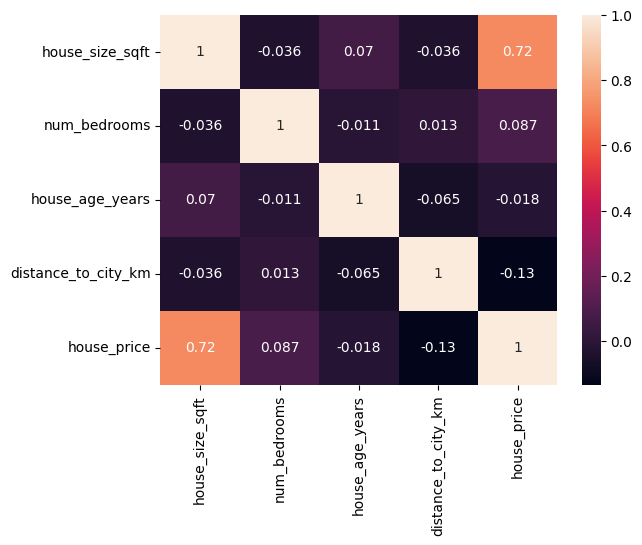

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.show()

In [ ]:
corr = df.corr(numeric_only=True)
print(corr)

                     house_size_sqft  num_bedrooms  house_age_years  \
house_size_sqft             1.000000     -0.035798         0.070257   
num_bedrooms               -0.035798      1.000000        -0.011438   
house_age_years             0.070257     -0.011438         1.000000   
distance_to_city_km        -0.036103      0.013089        -0.064614   
house_price                 0.723882      0.086803        -0.017810   

                     distance_to_city_km  house_price  
house_size_sqft                -0.036103     0.723882  
num_bedrooms                    0.013089     0.086803  
house_age_years                -0.064614    -0.017810  
distance_to_city_km             1.000000    -0.132264  
house_price                    -0.132264     1.000000  


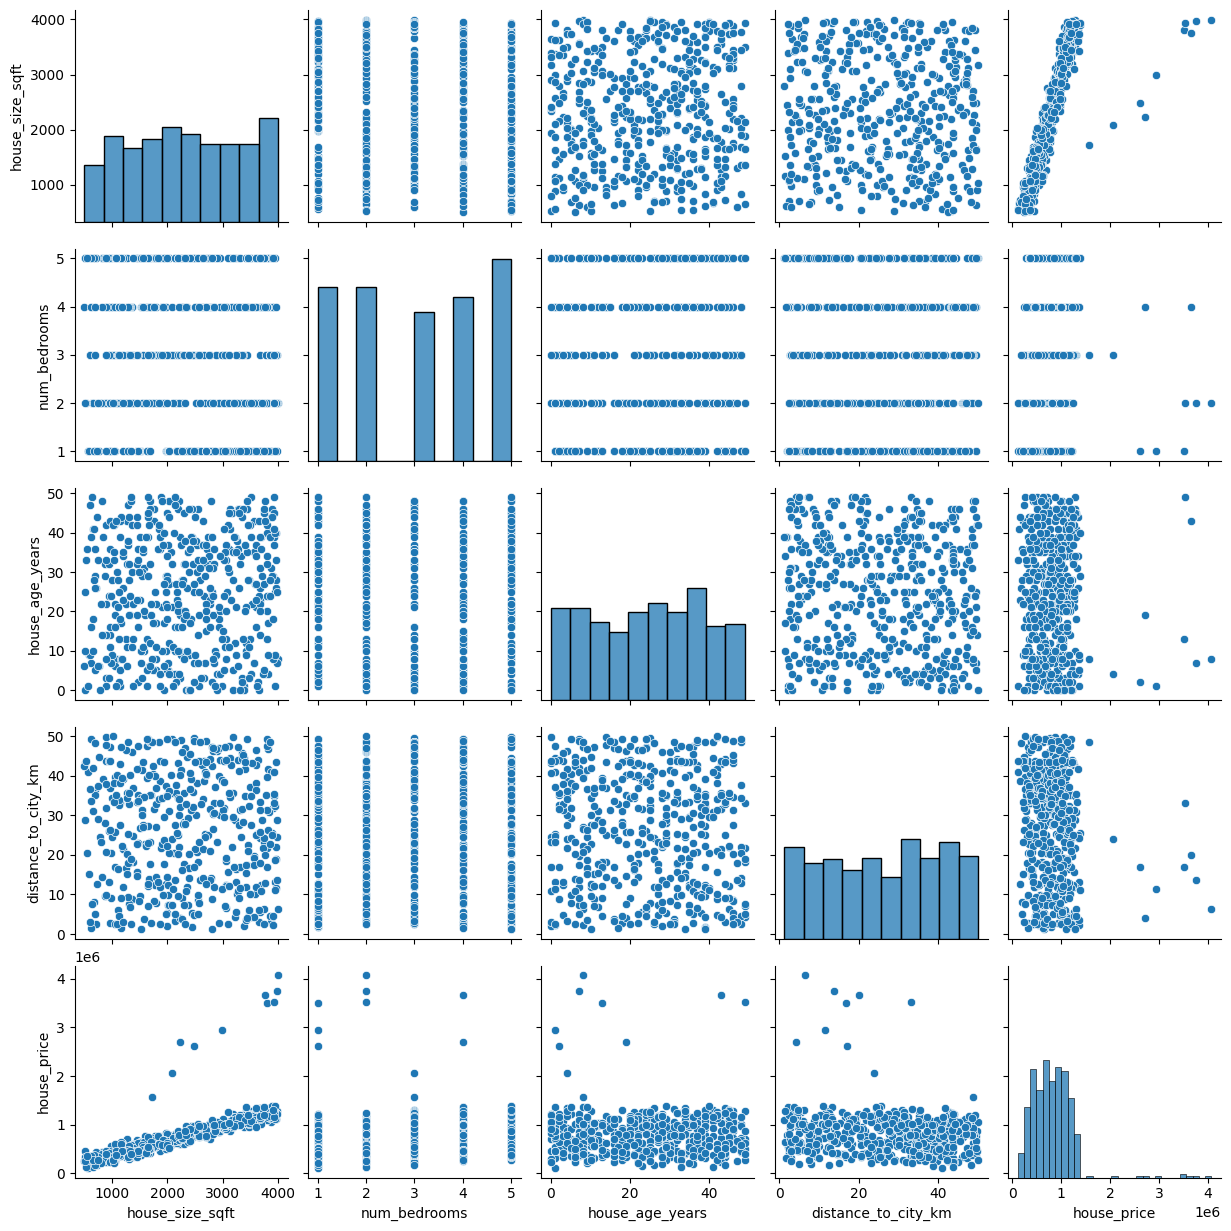

In [ ]:
sns.pairplot(df)

Text(0.5, 1.0, 'House Size vs. House Price')

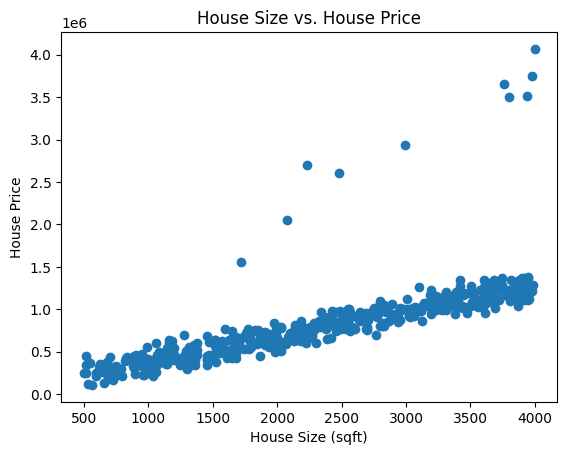

In [ ]:
plt.scatter(df['house_size_sqft'], df['house_price'])
plt.xlabel("House Size (sqft)")
plt.ylabel("House Price")
plt.title("House Size vs. House Price")

Text(0.5, 1.0, 'number of bedrooms vs. House Price')

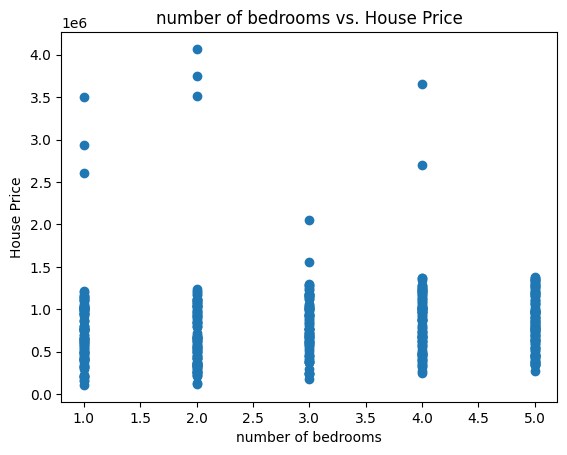

In [ ]:
plt.scatter(df['num_bedrooms'], df['house_price'])
plt.xlabel("number of bedrooms")
plt.ylabel("House Price")
plt.title("number of bedrooms vs. House Price")

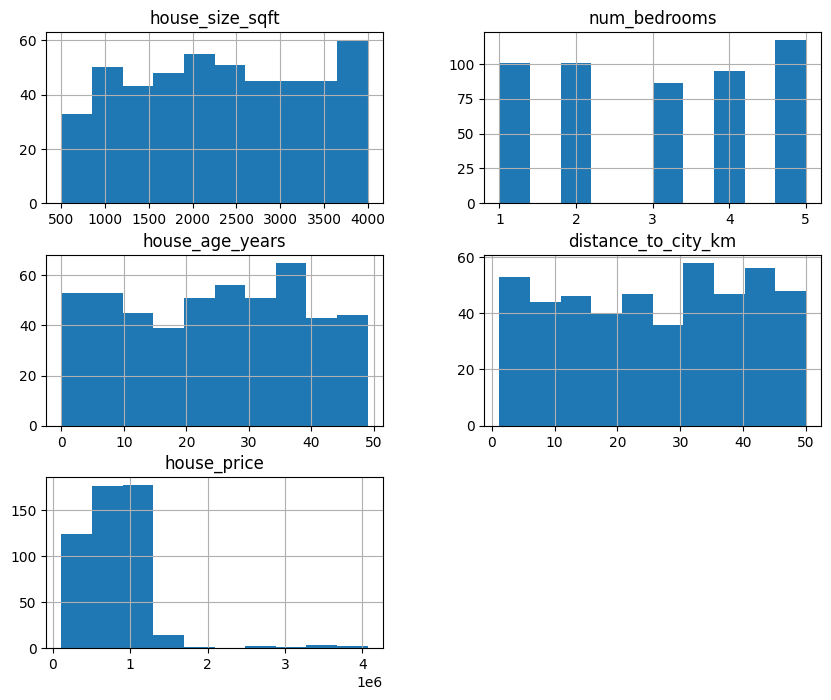

In [ ]:
import matplotlib.pyplot as plt

df.hist(figsize=(10,8))
plt.show()

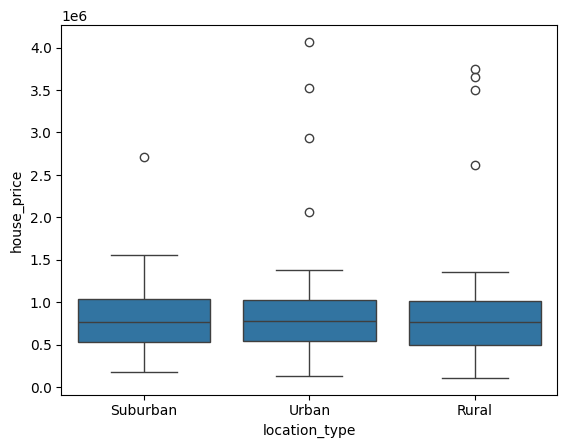

In [ ]:
sns.boxplot(x='location_type',y='house_price',data=df)
plt.show()

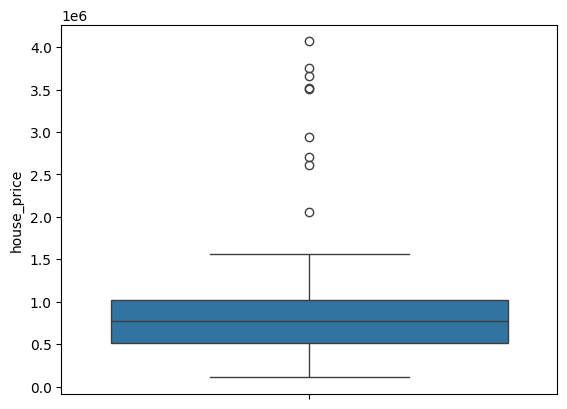

In [ ]:
sns.boxplot(df['house_price'])
plt.show()

In [ ]:
fcdf=pd.get_dummies(df,columns=['location_type'],drop_first=True)

In [ ]:
Q1=df["house_price"].quantile(0.25)
Q3=df["house_price"].quantile(0.75)
IQR =Q3-Q1

lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR

df=df[(df["house_price"]>=lower_bound) & (df["house_price"]<=upper_bound)]

In [ ]:
from sklearn.model_selection import train_test_split

X=df.drop('house_price',axis=1)
y=df['house_price']

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
from sklearn.linear_model import LinearRegression

model=LinearRegression()
model.fit(X_train,y_train)


In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

rmse = np.sqrt(mse)

print("Mean Squared Error:", mse)
print("R-squared:", r2)
print("rmse",rmse)

Mean Squared Error: 98341378984.68336
R-squared: 0.5365912178799455
rmse 313594.2904210524


In [ ]:
pd.DataFrame({
    'Feature':X.columns,
    'Coefficient':model.coef_
})

,Feature,Coefficient
0,house_size_sqft,338.550558
1,num_bedrooms,38233.067216
2,house_age_years,-1835.604090
3,distance_to_city_km,-3429.929138
4,location_type_Suburban,-43387.641196
5,location_type_Urban,-40580.710941
